In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# loading the processed data
crypto_df = pd.read_csv("../data/processed/crypto_prices_processed.csv")
crypto_df["Date"] = pd.to_datetime(crypto_df["Date"])

crypto_df.head()

,Date,coin,Open,High,Low,Close,Volume,daily_return,cumulative_return
0,2020-01-01,ADA,0.032832,0.033813,0.032704,0.033458,22948374,NaN,NaN
1,2020-01-02,ADA,0.033474,0.033507,0.032448,0.032751,20843934,-0.021131,-0.021131
2,2020-01-03,ADA,0.032748,0.034427,0.032491,0.034180,30162644,0.043632,0.021579
3,2020-01-04,ADA,0.034191,0.034685,0.033872,0.034595,29535781,0.012142,0.033983
4,2020-01-05,ADA,0.034574,0.035356,0.034545,0.034721,21479178,0.003642,0.037749


## VOLATILITY (Core Concept)

In [4]:
# Annualized volatility 
volatility = crypto_df.groupby("coin")["daily_return"].std() * np.sqrt(252)

volatility.sort_values(ascending=False)

coin
DOGE    1.579542
SOL     1.009877
XRP     0.871087
DOT     0.865589
ADA     0.839066
LTC     0.725218
BNB     0.701631
ETH     0.677602
BTC     0.506322
Name: daily_return, dtype: float64

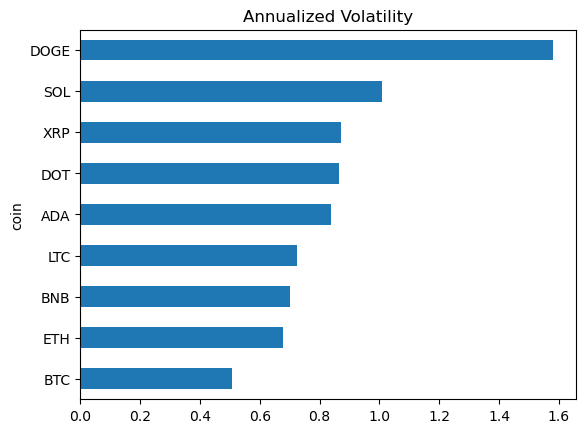

In [5]:
# Plotting the volatility
volatility.sort_values().plot(kind="barh", title="Annualized Volatility")
plt.show()

## ROLLING VOLATILITY (Time Series)

In [6]:
# Time series - rolling volatility
crypto_df["rolling_vol_30d"] = (
    crypto_df.groupby("coin")["daily_return"]
    .rolling(window=30)
    .std()
    .reset_index(level=0, drop=True)
)

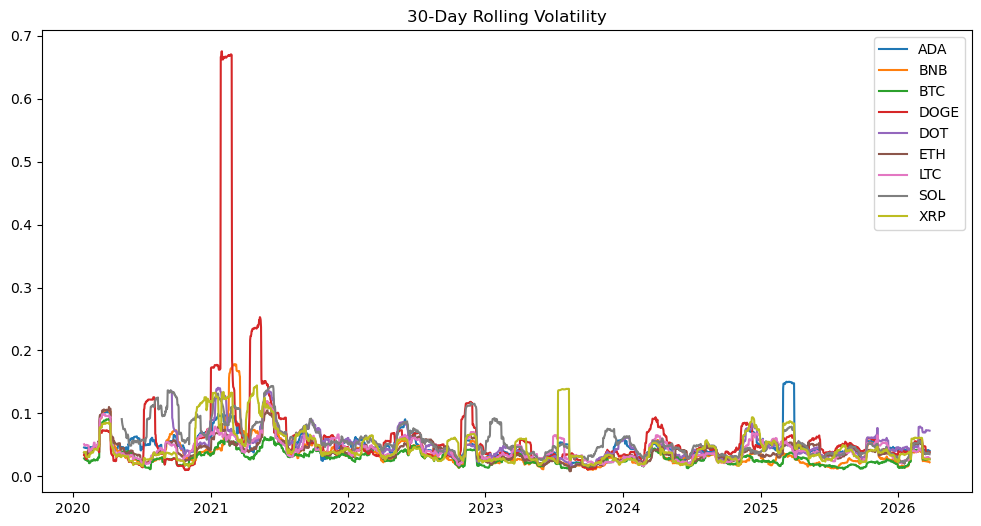

In [7]:
# Plotting the rolling volatility 
plt.figure(figsize=(12,6))

for coin in crypto_df["coin"].unique():
    subset = crypto_df[crypto_df["coin"] == coin]
    plt.plot(subset["Date"], subset["rolling_vol_30d"], label=coin)

plt.legend()
plt.title("30-Day Rolling Volatility")
plt.show()

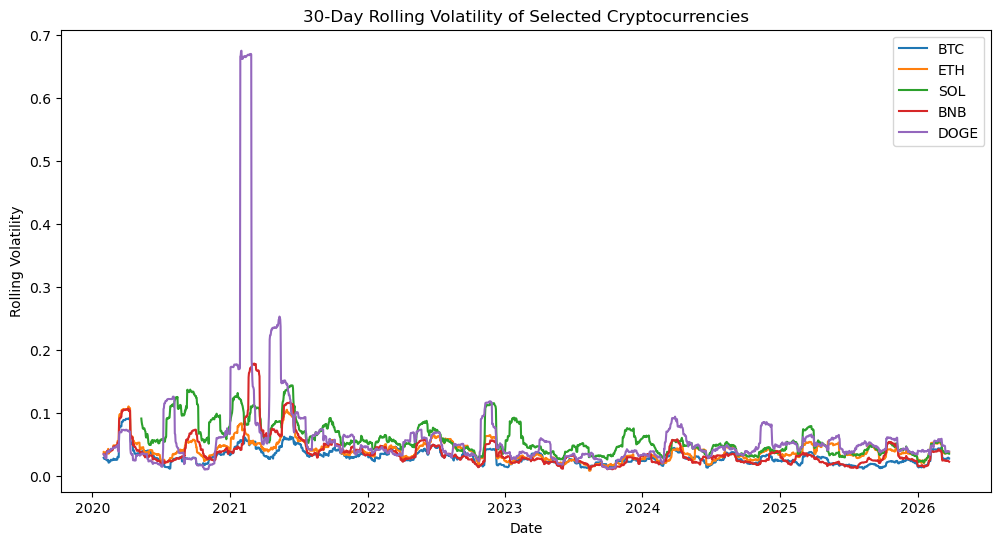

In [20]:
# 5 most relevant coins 
selected_coins = ["BTC", "ETH", "SOL", "BNB", "DOGE"]

plt.figure(figsize=(12,6))

for coin in selected_coins:
    subset = crypto_df[crypto_df["coin"] == coin]
    plt.plot(subset["Date"], subset["rolling_vol_30d"], label=coin)

plt.legend()
plt.title("30-Day Rolling Volatility of Selected Cryptocurrencies")
plt.xlabel("Date")
plt.ylabel("Rolling Volatility")
plt.show()

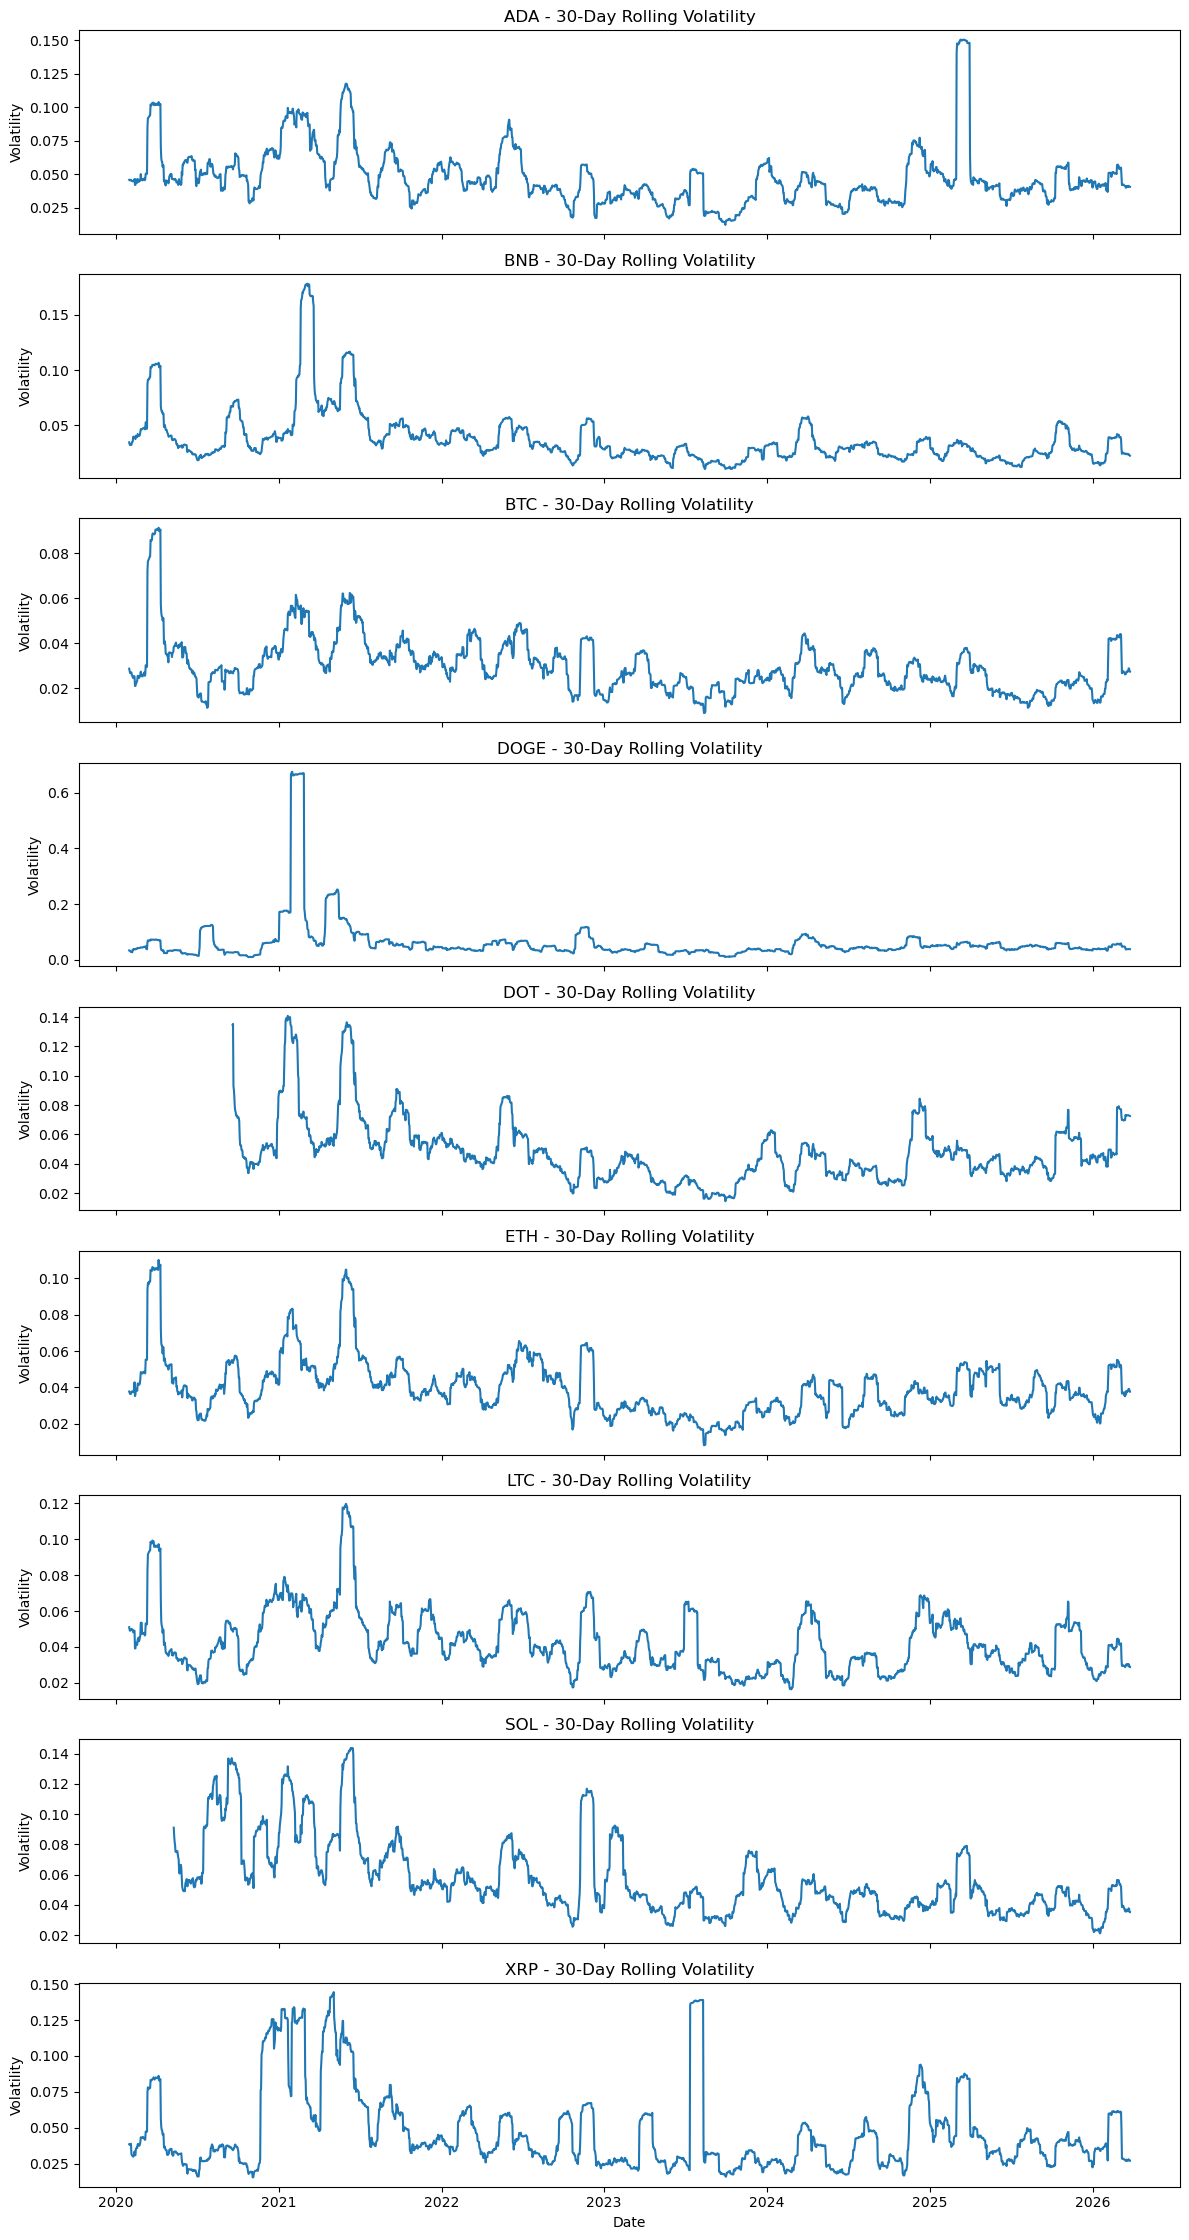

In [22]:
# One plot per coin
coins = crypto_df["coin"].unique()

fig, axes = plt.subplots(len(coins), 1, figsize=(12, 2.5 * len(coins)), sharex=True)

for ax, coin in zip(axes, coins):
    subset = crypto_df[crypto_df["coin"] == coin]
    ax.plot(subset["Date"], subset["rolling_vol_30d"])
    ax.set_title(f"{coin} - 30-Day Rolling Volatility")
    ax.set_ylabel("Volatility")

plt.xlabel("Date")
plt.tight_layout()
plt.show()

## RETURNS (Annualised)

In [8]:
# Annualized returns
returns = crypto_df.groupby("coin")["daily_return"].mean() * 252

returns.sort_values(ascending=False)

coin
DOGE    1.150029
SOL     1.033947
BNB     0.667650
XRP     0.581495
ADA     0.573003
ETH     0.543962
BTC     0.384326
LTC     0.300535
DOT     0.272070
Name: daily_return, dtype: float64

## SHARPE RATIO 

In [9]:
# Sharpe Ratio
sharpe_ratio = returns / volatility

sharpe_ratio.sort_values(ascending=False)

coin
SOL     1.023834
BNB     0.951569
ETH     0.802775
BTC     0.759055
DOGE    0.728077
ADA     0.682905
XRP     0.667551
LTC     0.414406
DOT     0.314318
Name: daily_return, dtype: float64

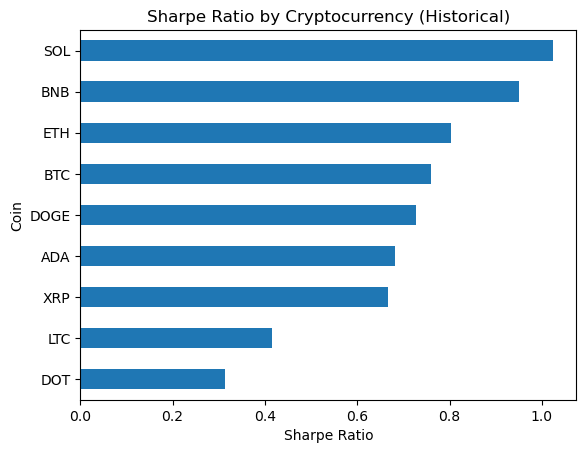

In [19]:
# Plottin the Sharpe Ratios
sharpe_ratio.sort_values().plot(kind="barh", title="Sharpe Ratio by Cryptocurrency (Historical)")
plt.xlabel("Sharpe Ratio")
plt.ylabel("Coin")
plt.show()

## DRAWDOWN

In [11]:
# Running max for drawdown
crypto_df["cum_max"] = crypto_df.groupby("coin")["Close"].cummax()

In [12]:
# Drawdown
crypto_df["drawdown"] = (crypto_df["Close"] / crypto_df["cum_max"]) - 1

In [13]:
# Max drawdown per coin
max_drawdown = crypto_df.groupby("coin")["drawdown"].min()

max_drawdown.sort_values()

coin
DOT    -0.976992
SOL    -0.962725
DOGE   -0.922585
ADA    -0.918513
LTC    -0.887954
XRP    -0.832490
ETH    -0.793512
BTC    -0.766346
BNB    -0.708380
Name: drawdown, dtype: float64

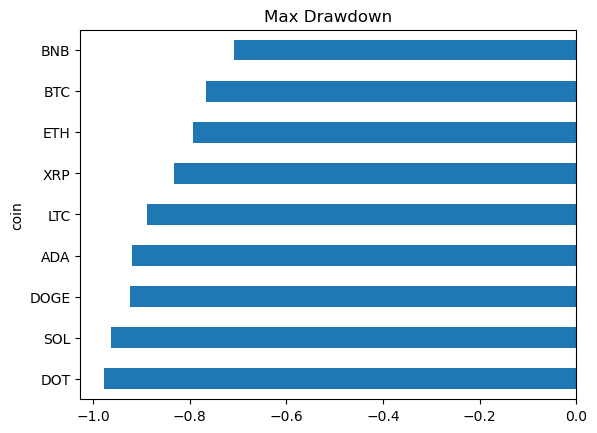

In [14]:
# Plotting drawdown
max_drawdown.sort_values().plot(kind="barh", title="Max Drawdown")
plt.show()

## CORRELATION

In [15]:
# Pivot table for correlation
returns_pivot = crypto_df.pivot(index="Date", columns="coin", values="daily_return")

In [16]:
# Correlation matrix
correlation_matrix = returns_pivot.corr()
correlation_matrix

coin,ADA,BNB,BTC,DOGE,DOT,ETH,LTC,SOL,XRP
coin,,,,,,,,,
ADA,1.000000,0.580460,0.670850,0.360394,0.677590,0.718733,0.667654,0.542239,0.622325
BNB,0.580460,1.000000,0.663762,0.265267,0.576796,0.678028,0.620897,0.520930,0.502227
BTC,0.670850,0.663762,1.000000,0.394097,0.645440,0.817631,0.736753,0.542739,0.570752
DOGE,0.360394,0.265267,0.394097,1.000000,0.325797,0.369302,0.367398,0.249683,0.284927
DOT,0.677590,0.576796,0.645440,0.325797,1.000000,0.707147,0.669243,0.566686,0.518703
ETH,0.718733,0.678028,0.817631,0.369302,0.707147,1.000000,0.762821,0.611183,0.598868
LTC,0.667654,0.620897,0.736753,0.367398,0.669243,0.762821,1.000000,0.502185,0.619025
SOL,0.542239,0.520930,0.542739,0.249683,0.566686,0.611183,0.502185,1.000000,0.453502
XRP,0.622325,0.502227,0.570752,0.284927,0.518703,0.598868,0.619025,0.453502,1.000000


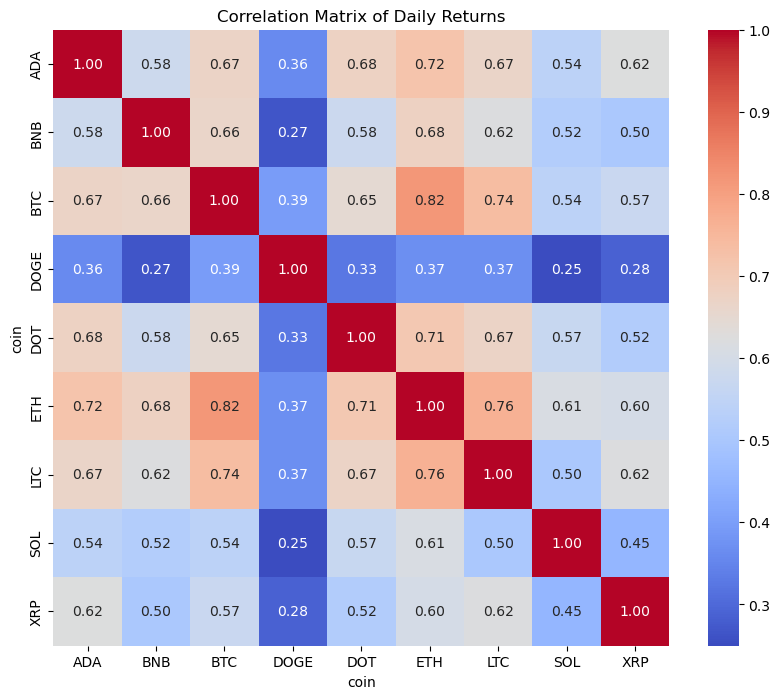

In [18]:
# Heatmap of the correlation matrix
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Correlation Matrix of Daily Returns")
plt.show()

# Inicial interpretations

### Sharpe ratio insight
Among the selected cryptocurrencies, SOL and BNB showed the strongest historical risk-adjusted returns, while BTC and ETH also performed well. This suggests that some altcoins outperformed not only in return but also relative to the level of risk taken.

### Correlation insight
Most assets showed moderate to high positive correlation, which means diversification within crypto can reduce some risk, but not eliminate it completely. DOGE stood out as one of the least correlated assets in the sample.